<a href="https://colab.research.google.com/github/Manish927/EDA-Data-Science/blob/main/kmeans_clustering_activity_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np; import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings; warnings.filterwarnings('ignore')
import os; os.environ['LOKY_MAX_CPU_COUNT'] = '1'

In [5]:
X = pd.read_csv('/content/carprices_dataset.csv'); X.sample(2)

,enginesize,horsepower,citympg,highwaympg
43,111,78,24,29
53,91,68,31,38


In [6]:
X.shape

(205, 4)

In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   enginesize  205 non-null    int64
 1   horsepower  205 non-null    int64
 2   citympg     205 non-null    int64
 3   highwaympg  205 non-null    int64
dtypes: int64(4)
memory usage: 6.5 KB


In [8]:
X.describe()

,enginesize,horsepower,citympg,highwaympg
count,205.000000,205.000000,205.000000,205.000000
mean,126.907317,104.117073,25.219512,30.751220
std,41.642693,39.544167,6.542142,6.886443
min,61.000000,48.000000,13.000000,16.000000
25%,97.000000,70.000000,19.000000,25.000000
50%,120.000000,95.000000,24.000000,30.000000
75%,141.000000,116.000000,30.000000,34.000000
max,326.000000,288.000000,49.000000,54.000000


# Task 1
### Feature Scaling
- Scale all features using `StandardScaler()` from `sklearn.preprocessing`

In [9]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()


,enginesize,horsepower,citympg,highwaympg
0,0.074449,0.174483,-0.646553,-0.546059
1,0.074449,0.174483,-0.646553,-0.546059
2,0.604046,1.264536,-0.953012,-0.691627
3,-0.431076,-0.053668,-0.186865,-0.109354
4,0.218885,0.275883,-1.106241,-1.273900


# Task 2
### Clustering for Various K
- Apply K-means clustering on the sclaed data using `KMeans()` from `sklearn.cluster` with `init = 'random'`, `random_state = 9001`,on the scaled data using random initialisation, `random_state = 9001`, and `n_init = 1`
- Compute and analyse the inertia or WCSS and the Silhouette score for values of K from 2 to 10

In [11]:

inertia = []
sil_scores = []
K_values = range(2,11)

for k in K_values:
    kmeans = KMeans(n_clusters=k, init='random', random_state=9001, n_init=1)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({
    'K': list(K_values),
    'Inertia': inertia,
    'SilhouetteScore': sil_scores
})

results


,K,Inertia,SilhouetteScore
0,2,385.554310,0.467324
1,3,294.677428,0.417685
2,4,283.589346,0.378118
3,5,180.762054,0.418117
4,6,129.745454,0.424355
5,7,101.551570,0.414995
6,8,97.141314,0.379716
7,9,98.165159,0.314835
8,10,97.496943,0.316540


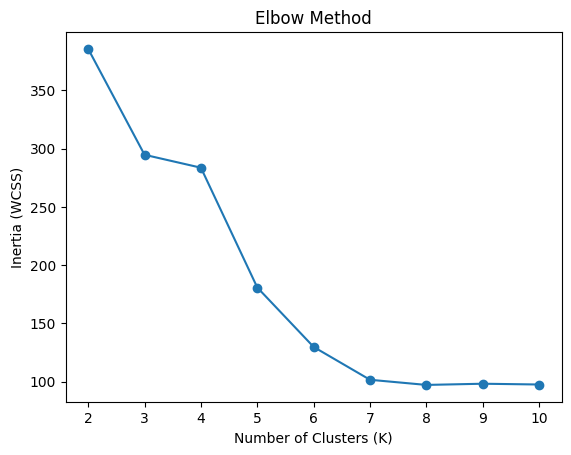

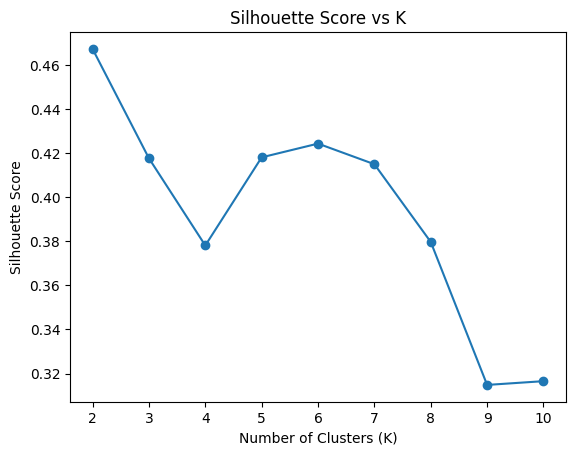

In [12]:

import matplotlib.pyplot as plt

plt.figure()
plt.plot(results['K'], results['Inertia'], marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method')
plt.show()

plt.figure()
plt.plot(results['K'], results['SilhouetteScore'], marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K')
plt.show()
